<a href="https://colab.research.google.com/github/ginnelalikitha/python/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [61]:
df_to_save = df

df_to_save.to_csv("iris_dataset.csv", index=False)

#understand data

In [62]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [63]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [64]:
df.shape

(150, 5)

In [65]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

#identify data types


In [66]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64


In [67]:
numeric_values=df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_values

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target']

#handling missing values


In [68]:
missing_count=df.isnull().sum()
missing_count

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


#outliers

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']


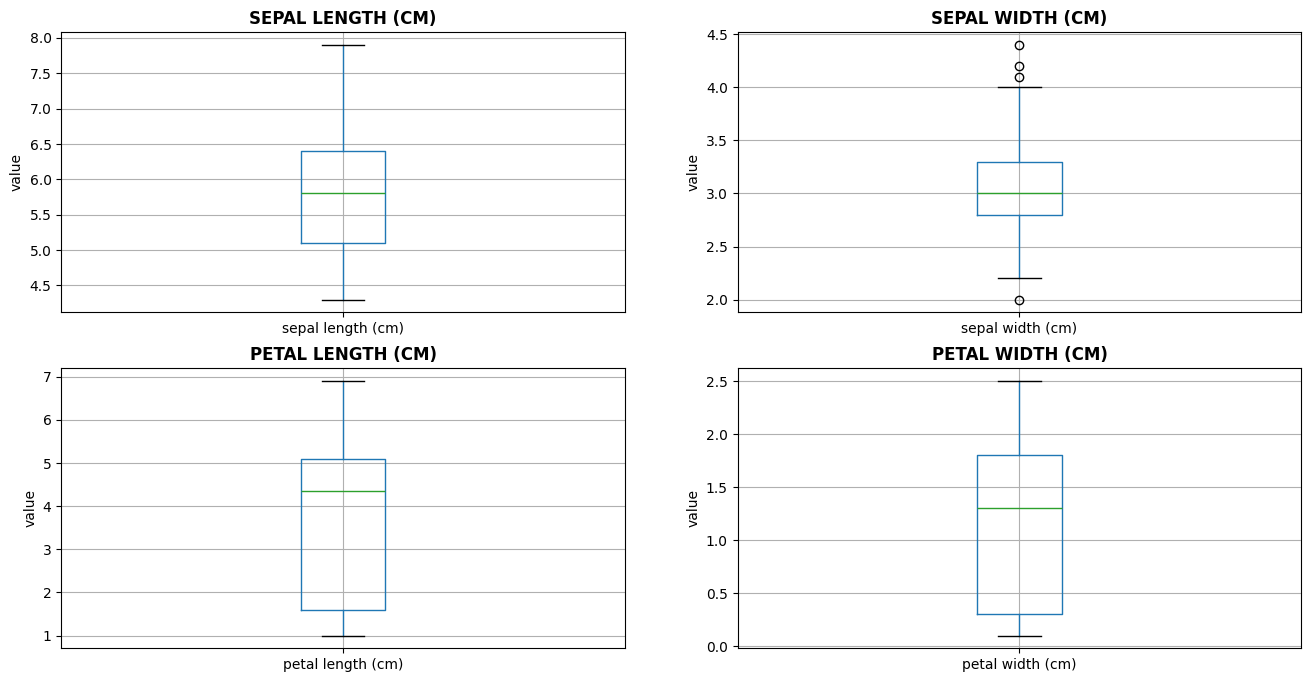

In [69]:
numeric_values=df.select_dtypes(include=['int64','float64']).columns
numeric_values=[col for col in numeric_values if col not in ['target']]


fig,axes=plt.subplots(2,2,figsize=(16,8))
axes=axes.ravel()

print(df.columns.tolist())

for idx,column in enumerate(numeric_values[:4]):
  if idx<len(axes):
    df.boxplot(column=column,ax=axes[idx])
    axes[idx].set_title(f"{column.upper()}",fontweight='bold')
    axes[idx].set_ylabel('value')

for idx in range(len(axes),len(numeric_values)):
  axes[idx].axes='off'

  plt.tight_layout()
  plt.show()


#Inter quartile range-- to know exact count of outliers


In [70]:
Q1=df['sepal width (cm)'].quantile(0.25)
Q3=df['sepal width (cm)'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['sepal width (cm)']<(Q1-1.5*IQR))|(df['sepal width (cm)']>(Q1+1.5*IQR))]
outliers

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
10,5.4,3.7,1.5,0.2,0
14,5.8,4.0,1.2,0.2,0
15,5.7,4.4,1.5,0.4,0
16,5.4,3.9,1.3,0.4,0
18,5.7,3.8,1.7,0.3,0
19,5.1,3.8,1.5,0.3,0
21,5.1,3.7,1.5,0.4,0
22,4.6,3.6,1.0,0.2,0


In [71]:
print(f"number of outliers:{len(outliers)}")

number of outliers:20


#solving outliers

In [72]:
df['sepal width (cm)'].describe()

,sepal width (cm)
count,150.000000
mean,3.057333
std,0.435866
min,2.000000
25%,2.800000
50%,3.000000
75%,3.300000
max,4.400000


In [74]:
df_outliers=df.copy()


df_outliers['sepal width_capped']=df_outliers['sepal width (cm)'].clip(
    lower=lower_bound,
    upper=upper_bound
)
print(f"original sepal width:{df_outliers['sepal width (cm)'].min():.2f}-{df_outliers['sepal width (cm)'].max():.2f}")
print(f"after capping sepal width:{df_outliers['sepal width_capped'].min():.2f}-{df_outliers['sepal width_capped'].max():.2f}")

#completely removing outliers

df_no_outliers=df[
    (df['sepal width (cm)']>=lower_bound)&(df['sepal width (cm)']<=upper_bound)
    ]
print(f"shape before:{df.shape}")
print(f"shape after:{df_no_outliers.shape}")

#skew
df_outliers['sepal width_log']=np.log1p(df_outliers['sepal width (cm)'])

print(f"original skewness:{df_outliers['sepal width (cm)'].skew():.3f}")
print(f"original skewness:{df_outliers['sepal width_log'].skew():.3f}")




original sepal width:2.00-4.40
after capping sepal width:2.05-4.05
shape before:(150, 5)
shape after:(146, 5)
original skewness:0.319
original skewness:-0.013
